# EDA 11 - Revenue by Product Category

This notebook analyzes revenue contribution, concentration, trend, and category-mix changes using `orders.csv`, `order_items.csv`, and `products.csv`. Category findings are exploratory signals for business interpretation and leakage-safe forecast feature engineering.

## 1. Setup and file discovery

Locate the required CSV files recursively from the current working directory and configure common analysis settings. Outputs are displayed in the notebook and are not saved to separate files.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 260)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path(os.getcwd())
REQUIRED_FILES = ["orders.csv", "order_items.csv", "products.csv"]
OPTIONAL_FILES = ["sales.csv"]
FILES_TO_LOAD = REQUIRED_FILES + OPTIONAL_FILES
TOP_N_CATEGORIES = 8

warning_messages = []
loaded_files = {}
file_paths = {}
analysis_ready = False

category_items = pd.DataFrame()
category_revenue = pd.DataFrame()
concentration_df = pd.DataFrame()
monthly_category = pd.DataFrame()
monthly_pivot = pd.DataFrame()
growth_df = pd.DataFrame()
fastest_growing_df = pd.DataFrame()
fastest_declining_df = pd.DataFrame()
monthly_share_plot_df = pd.DataFrame()
feature_preview = pd.DataFrame()
revenue_validation_df = pd.DataFrame()

top_category_names = []
bottom_category_names = []
concentration_statement = "Not evaluated."
mix_change_statement = "Not evaluated."
forecast_feature_warning = "Future category mix must not be used directly for forecasting unless it is separately forecasted."
recommended_category_features = [
    "top_category_revenue_lag",
    "category_revenue_share_lag_30",
    "category_mix_lag_30",
    "top_1_category_share_lag_30",
    "top_3_category_share_lag_30",
    "category_concentration_lag_30",
]


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

for filename in FILES_TO_LOAD:
    matches = sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))
    file_paths[filename] = matches[0] if matches else None

file_discovery_df = pd.DataFrame([
    {
        "file": filename,
        "required": filename in REQUIRED_FILES,
        "found": file_paths[filename] is not None,
        "path": str(file_paths[filename].relative_to(PROJECT_ROOT)) if file_paths[filename] else None,
        "match_count": len(sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))),
    }
    for filename in FILES_TO_LOAD
])

missing_files = [filename for filename in REQUIRED_FILES if file_paths[filename] is None]
if missing_files:
    warning_messages.append("Required files not found: " + ", ".join(missing_files))

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)

Project root: D:\Code\Datathon 2026


,file,required,found,path,match_count
0,orders.csv,True,True,datathon-2026-round-1\orders.csv,1
1,order_items.csv,True,True,datathon-2026-round-1\order_items.csv,1
2,products.csv,True,True,datathon-2026-round-1\products.csv,1
3,sales.csv,False,True,datathon-2026-round-1\sales.csv,1


## 2. Load orders, order_items, products, and optional sales totals

Load each required file safely with pandas. `sales.csv` is optional and is used only to validate that reconstructed item revenue reconciles to the official revenue series.

In [2]:
load_rows = []
for filename in FILES_TO_LOAD:
    path = file_paths.get(filename)
    if path is None:
        loaded_files[filename] = None
        load_rows.append({"file": filename, "loaded": False, "rows": np.nan, "columns": np.nan, "error": "file not found"})
        continue
    try:
        df = pd.read_csv(path, low_memory=False)
        loaded_files[filename] = df
        load_rows.append({"file": filename, "loaded": True, "rows": len(df), "columns": len(df.columns), "error": ""})
    except Exception as exc:
        loaded_files[filename] = None
        warning_messages.append(f"Could not load {filename}: {repr(exc)}")
        load_rows.append({"file": filename, "loaded": False, "rows": np.nan, "columns": np.nan, "error": repr(exc)})

load_summary_df = pd.DataFrame(load_rows)
display(load_summary_df)

for filename in FILES_TO_LOAD:
    df = loaded_files.get(filename)
    if df is not None:
        print(f"Preview: {filename}")
        display(df.head())

,file,loaded,rows,columns,error
0,orders.csv,True,646945,8,
1,order_items.csv,True,714669,7,
2,products.csv,True,2412,8,
3,sales.csv,True,3833,3,


Preview: orders.csv


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


Preview: order_items.csv


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


Preview: products.csv


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


Preview: sales.csv


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Identify key, date, category, and revenue columns

Infer the order key, product key, order date, category, quantity, price, discount, and revenue-related fields. For this dataset, `unit_price` is already the post-promotion unit price, so item revenue is reconstructed as `quantity * unit_price`. `discount_amount` is kept as a discount field and must not be treated as revenue.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    name_points = 0
    if name in {"date", "order_date", "created_at", "timestamp", "transaction_date", "sales_date"}:
        name_points += 5
    elif "date" in name_tokens or "date" in name or "timestamp" in name or "time" in name:
        name_points += 3

    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {"column": column_name, "date_score": -5.0, "date_parse_success": 0.0, "plausible_date_share": 0.0}

    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parse_success = float(parsed[mask].notna().mean()) if non_empty else 0.0
    parsed_valid = parsed[mask].dropna()
    if len(parsed_valid):
        plausible_share = float(parsed_valid.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31")).mean())
        unique_dates = int(parsed_valid.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0
    score = name_points + 3 * parse_success + 2 * plausible_share + min(unique_dates / 20, 1)
    return {"column": column_name, "date_score": round(score, 4), "date_parse_success": round(parse_success, 4), "plausible_date_share": round(plausible_share, 4)}


def string_key_values(series):
    return series.dropna().astype("string").str.strip()


def key_candidates(df, key_kind):
    if df is None or df.empty:
        return []
    candidates = []
    for col in df.columns:
        name = normalize_name(col)
        name_tokens = set(name.split("_"))
        score = 0
        if key_kind == "order":
            if name in {"order_id", "orderid", "id_order"}:
                score += 8
            if "order" in name_tokens or "order" in name:
                score += 4
        if key_kind == "product":
            if name in {"product_id", "productid", "sku", "item_id"}:
                score += 8
            if "product" in name_tokens or "product" in name or "sku" in name:
                score += 4
        if "id" in name_tokens or name.endswith("_id") or name == "id":
            score += 3
        if "date" in name or "time" in name:
            score -= 5
        if score > 0:
            candidates.append((col, score))
    if not candidates:
        for col in df.columns:
            if df[col].nunique(dropna=True) > 1:
                candidates.append((col, 0))
    return candidates


def choose_join_key(left_df, right_df, key_kind):
    rows = []
    for left_col, left_name_score in key_candidates(left_df, key_kind):
        left_values = set(string_key_values(left_df[left_col]).unique())
        for right_col, right_name_score in key_candidates(right_df, key_kind):
            right_values = set(string_key_values(right_df[right_col]).unique())
            if not left_values or not right_values:
                overlap_rate = 0.0
            else:
                overlap_rate = len(left_values & right_values) / max(1, len(left_values))
            score = left_name_score + right_name_score + 10 * overlap_rate
            rows.append({
                "left_column": left_col,
                "right_column": right_col,
                "key_kind": key_kind,
                "score": score,
                "left_name_score": left_name_score,
                "right_name_score": right_name_score,
                "left_unique": len(left_values),
                "right_unique": len(right_values),
                "left_unique_overlap_rate": overlap_rate,
            })
    result = pd.DataFrame(rows).sort_values(["score", "left_unique_overlap_rate"], ascending=False) if rows else pd.DataFrame()
    if result.empty:
        return None, None, result
    best = result.iloc[0]
    if best["left_unique_overlap_rate"] < 0.05 and best["score"] < 8:
        return None, None, result
    return best["left_column"], best["right_column"], result


def choose_date_column(df):
    if df is None or df.empty:
        return None, pd.DataFrame()
    candidates = pd.DataFrame([date_score(col, df[col]) for col in df.columns])
    candidates = candidates.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    if candidates.empty:
        return None, candidates
    best = candidates.iloc[0]
    if best["date_parse_success"] >= 0.50 and best["plausible_date_share"] >= 0.50:
        return best["column"], candidates
    return None, candidates


def choose_category_column(products_df):
    if products_df is None or products_df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in products_df.columns:
        name = normalize_name(col)
        values = products_df[col]
        non_null = values.notna().sum()
        unique = values.nunique(dropna=True)
        unique_rate = unique / max(non_null, 1)
        score = 0
        if name == "category":
            score += 10
        if "category" in name or "department" in name or "class" in name:
            score += 6
        if pd.api.types.is_object_dtype(values) or pd.api.types.is_string_dtype(values):
            score += 2
        if 2 <= unique <= 100:
            score += 2
        if unique_rate > 0.75:
            score -= 3
        if any(term in name for term in ["id", "price", "cost", "date", "size", "color"]):
            score -= 3
        rows.append({"column": col, "category_score": score, "unique_values": unique, "unique_rate": unique_rate})
    candidates = pd.DataFrame(rows).sort_values(["category_score", "unique_values"], ascending=[False, True])
    best = candidates.iloc[0] if len(candidates) else None
    if best is not None and best["category_score"] > 0:
        return best["column"], candidates
    return None, candidates


def choose_numeric_by_terms(df, positive_terms, negative_terms=None):
    negative_terms = negative_terms or []
    if df is None or df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in df.columns:
        name = normalize_name(col)
        values = numeric_series(df[col])
        non_empty = max(int(non_empty_mask(df[col]).sum()), 1)
        numeric_success = values.notna().sum() / non_empty
        if numeric_success < 0.70:
            continue
        score = numeric_success
        for term in positive_terms:
            if term in name:
                score += 5
        for term in negative_terms:
            if term in name:
                score -= 5
        if values.dropna().std(ddof=1) > 0:
            score += 1
        rows.append({"column": col, "score": score, "numeric_parse_success": numeric_success, "mean": values.mean(), "std": values.std(ddof=1)})
    candidates = pd.DataFrame(rows).sort_values("score", ascending=False) if rows else pd.DataFrame()
    if candidates.empty or candidates.iloc[0]["score"] <= 1:
        return None, candidates
    return candidates.iloc[0]["column"], candidates


orders = loaded_files.get("orders.csv")
order_items = loaded_files.get("order_items.csv")
products = loaded_files.get("products.csv")

if orders is None or order_items is None or products is None:
    order_id_items_col = order_id_orders_col = None
    product_id_items_col = product_id_products_col = None
    order_date_col = category_col = quantity_col = price_col = discount_col = direct_revenue_col = None
    revenue_method = "not available"
    detection_summary_df = pd.DataFrame([{"warning": "One or more required files were not loaded."}])
else:
    order_id_items_col, order_id_orders_col, order_key_candidates_df = choose_join_key(order_items, orders, "order")
    product_id_items_col, product_id_products_col, product_key_candidates_df = choose_join_key(order_items, products, "product")
    order_date_col, order_date_candidates_df = choose_date_column(orders)
    category_col, category_candidates_df = choose_category_column(products)

    quantity_col, quantity_candidates_df = choose_numeric_by_terms(order_items, ["quantity", "qty", "units"], ["price", "discount", "amount"])
    price_col, price_candidates_df = choose_numeric_by_terms(order_items, ["unit_price", "price", "sales_price", "item_price"], ["discount", "quantity", "qty", "id"])
    discount_col, discount_candidates_df = choose_numeric_by_terms(order_items, ["discount"], ["id", "date"])
    direct_revenue_col, direct_revenue_candidates_df = choose_numeric_by_terms(
        order_items,
        ["revenue", "line_total", "item_total", "sales_amount", "net_sales", "subtotal", "line_subtotal", "total"],
        ["discount", "price", "cost", "cogs", "quantity", "qty", "id"],
    )

    if quantity_col is not None and price_col is not None:
        revenue_method = f"inferred: {quantity_col} * {price_col} (unit price is post-discount)"
    elif direct_revenue_col is not None:
        revenue_method = f"direct column: {direct_revenue_col}"
    else:
        revenue_method = "not available"

    detection_summary_df = pd.DataFrame([{
        "order_id_in_order_items": order_id_items_col,
        "order_id_in_orders": order_id_orders_col,
        "product_id_in_order_items": product_id_items_col,
        "product_id_in_products": product_id_products_col,
        "order_date_column": order_date_col,
        "category_column": category_col,
        "direct_revenue_column": direct_revenue_col,
        "quantity_column": quantity_col,
        "price_column": price_col,
        "discount_column": discount_col,
        "revenue_method": revenue_method,
    }])

display(detection_summary_df)

for label, df in [
    ("Order key candidates", locals().get("order_key_candidates_df", pd.DataFrame())),
    ("Product key candidates", locals().get("product_key_candidates_df", pd.DataFrame())),
    ("Order date candidates", locals().get("order_date_candidates_df", pd.DataFrame())),
    ("Category candidates", locals().get("category_candidates_df", pd.DataFrame())),
    ("Direct revenue candidates", locals().get("direct_revenue_candidates_df", pd.DataFrame())),
    ("Quantity candidates", locals().get("quantity_candidates_df", pd.DataFrame())),
    ("Price candidates", locals().get("price_candidates_df", pd.DataFrame())),
    ("Discount candidates", locals().get("discount_candidates_df", pd.DataFrame())),
]:
    if isinstance(df, pd.DataFrame) and not df.empty:
        print(label)
        display(df.head(10))

,order_id_in_order_items,order_id_in_orders,product_id_in_order_items,product_id_in_products,order_date_column,category_column,direct_revenue_column,quantity_column,price_column,discount_column,revenue_method
0,order_id,order_id,product_id,product_id,order_date,category,None,quantity,unit_price,discount_amount,inferred: quantity * unit_price (unit price is post-discount)


Order key candidates


,left_column,right_column,key_kind,score,left_name_score,right_name_score,left_unique,right_unique,left_unique_overlap_rate
0,order_id,order_id,order,40.000000,15,15,646945,646945,1.000000
4,product_id,order_id,order,25.484355,3,15,1598,646945,0.748436
1,order_id,customer_id,order,19.076908,15,3,646945,90246,0.107691
2,order_id,order_status,order,19.000000,15,4,646945,6,0.000000
3,order_id,order_source,order,19.000000,15,4,646945,6,0.000000
8,promo_id,order_id,order,18.000000,3,15,50,646945,0.000000
12,promo_id_2,order_id,order,18.000000,3,15,2,646945,0.000000
5,product_id,customer_id,order,11.782228,3,3,1598,90246,0.578223
6,product_id,order_status,order,7.000000,3,4,1598,6,0.000000
7,product_id,order_source,order,7.000000,3,4,1598,6,0.000000


Product key candidates


,left_column,right_column,key_kind,score,left_name_score,right_name_score,left_unique,right_unique,left_unique_overlap_rate
2,product_id,product_id,product,40.000000,15,15,1598,2412,1.000000
3,product_id,product_name,product,19.000000,15,4,1598,2172,0.000000
0,order_id,product_id,product,18.028163,3,15,646945,2412,0.002816
4,promo_id,product_id,product,18.000000,3,15,50,2412,0.000000
6,promo_id_2,product_id,product,18.000000,3,15,2,2412,0.000000
1,order_id,product_name,product,7.000000,3,4,646945,2172,0.000000
5,promo_id,product_name,product,7.000000,3,4,50,2172,0.000000
7,promo_id_2,product_name,product,7.000000,3,4,2,2172,0.000000


...

,column,score,numeric_parse_success,mean,std
2,quantity,7.0,1.0,4.495988,2.290143
0,order_id,2.0,1.0,411615.076561,240480.310686
1,product_id,2.0,1.0,1234.931370,691.332564
3,unit_price,-3.0,1.0,5114.690157,3774.817912
4,discount_amount,-8.0,1.0,1048.887415,2280.530606


Price candidates


,column,score,numeric_parse_success,mean,std
3,unit_price,12.0,1.0,5114.690157,3774.817912
0,order_id,-3.0,1.0,411615.076561,240480.310686
1,product_id,-3.0,1.0,1234.931370,691.332564
2,quantity,-3.0,1.0,4.495988,2.290143
4,discount_amount,-3.0,1.0,1048.887415,2280.530606


Discount candidates


,column,score,numeric_parse_success,mean,std
4,discount_amount,7.0,1.0,1048.887415,2280.530606
3,unit_price,2.0,1.0,5114.690157,3774.817912
2,quantity,2.0,1.0,4.495988,2.290143
0,order_id,-3.0,1.0,411615.076561,240480.310686
1,product_id,-3.0,1.0,1234.931370,691.332564


## 4. Build joined category-level dataset

Join `order_items` to `orders` by order ID and to `products` by product ID. Item-level revenue is either read directly or inferred from item price, quantity, and discount.

In [4]:
def compute_item_revenue(df):
    if quantity_col is not None and price_col is not None:
        quantity = numeric_series(df[quantity_col]).fillna(0)
        price = numeric_series(df[price_col]).fillna(0)
        return quantity * price
    if direct_revenue_col is not None and direct_revenue_col in df.columns:
        return numeric_series(df[direct_revenue_col])
    return pd.Series(np.nan, index=df.index)


required_detection = [
    order_id_items_col, order_id_orders_col, product_id_items_col, product_id_products_col,
    order_date_col, category_col,
]
if orders is None or order_items is None or products is None or any(value is None for value in required_detection) or revenue_method == "not available":
    analysis_ready = False
    missing_pieces = []
    if orders is None: missing_pieces.append("orders.csv")
    if order_items is None: missing_pieces.append("order_items.csv")
    if products is None: missing_pieces.append("products.csv")
    if order_id_items_col is None or order_id_orders_col is None: missing_pieces.append("order key")
    if product_id_items_col is None or product_id_products_col is None: missing_pieces.append("product key")
    if order_date_col is None: missing_pieces.append("order date")
    if category_col is None: missing_pieces.append("category")
    if revenue_method == "not available": missing_pieces.append("item revenue fields")
    warning_messages.append("Category analysis could not be fully prepared because these pieces are missing: " + ", ".join(missing_pieces))
    display(pd.DataFrame([{"ready": False, "missing_pieces": ", ".join(missing_pieces)}]))
else:
    orders_dim = orders.copy()
    products_dim = products.copy()
    order_duplicate_keys = int(orders_dim.duplicated(order_id_orders_col, keep=False).sum())
    product_duplicate_keys = int(products_dim.duplicated(product_id_products_col, keep=False).sum())
    if order_duplicate_keys:
        warning_messages.append(f"orders.csv has {order_duplicate_keys:,} rows on duplicated order keys; first row per key was used for joining.")
    if product_duplicate_keys:
        warning_messages.append(f"products.csv has {product_duplicate_keys:,} rows on duplicated product keys; first row per key was used for joining.")
    orders_dim = orders_dim.drop_duplicates(order_id_orders_col, keep="first")
    products_dim = products_dim.drop_duplicates(product_id_products_col, keep="first")

    items = order_items.copy()
    items["item_revenue"] = compute_item_revenue(items)

    joined_orders = items.merge(
        orders_dim[[order_id_orders_col, order_date_col]],
        left_on=order_id_items_col,
        right_on=order_id_orders_col,
        how="left",
        indicator="order_join_status",
        suffixes=("", "_orders"),
    )
    joined_full = joined_orders.merge(
        products_dim[[product_id_products_col, category_col]],
        left_on=product_id_items_col,
        right_on=product_id_products_col,
        how="left",
        indicator="product_join_status",
        suffixes=("", "_products"),
    )

    category_items = pd.DataFrame({
        "order_date": parse_datetime_series(joined_full[order_date_col]).dt.normalize(),
        "order_id": joined_full[order_id_items_col],
        "product_id": joined_full[product_id_items_col],
        "category": joined_full[category_col].astype("string").fillna("Unknown"),
        "revenue": numeric_series(joined_full["item_revenue"]),
        "order_join_status": joined_full["order_join_status"].astype(str),
        "product_join_status": joined_full["product_join_status"].astype(str),
    })
    if quantity_col is not None:
        category_items["quantity"] = numeric_series(joined_full[quantity_col])
    if price_col is not None:
        category_items["price"] = numeric_series(joined_full[price_col])
    if discount_col is not None:
        category_items["discount"] = numeric_series(joined_full[discount_col])

    before_filter_rows = len(category_items)
    invalid_date_rows = int(category_items["order_date"].isna().sum())
    invalid_revenue_rows = int(category_items["revenue"].isna().sum())
    category_items = category_items.dropna(subset=["order_date", "revenue"]).copy()
    category_items["month"] = category_items["order_date"].dt.to_period("M").dt.to_timestamp()
    category_items["category"] = category_items["category"].replace("", "Unknown").fillna("Unknown")

    analysis_ready = not category_items.empty
    total_item_revenue = float(category_items["revenue"].sum()) if analysis_ready else np.nan
    total_discount_amount = float(category_items["discount"].sum()) if analysis_ready and "discount" in category_items else np.nan
    sales = loaded_files.get("sales.csv")
    sales_revenue_total = np.nan
    sales_revenue_difference = np.nan
    sales_revenue_difference_pct = np.nan
    if sales is not None and not sales.empty:
        sales_revenue_col, sales_revenue_candidates_df = choose_numeric_by_terms(
            sales,
            ["revenue", "sales"],
            ["cost", "cogs", "discount", "id", "date"],
        )
        if sales_revenue_col is not None:
            sales_revenue_total = float(numeric_series(sales[sales_revenue_col]).sum())
            sales_revenue_difference = total_item_revenue - sales_revenue_total
            sales_revenue_difference_pct = sales_revenue_difference / sales_revenue_total if sales_revenue_total else np.nan

    build_summary_df = pd.DataFrame([{
        "ready": analysis_ready,
        "order_items_rows": len(order_items),
        "joined_rows_before_filter": before_filter_rows,
        "analysis_rows_after_filter": len(category_items),
        "invalid_order_date_rows": invalid_date_rows,
        "invalid_revenue_rows": invalid_revenue_rows,
        "negative_revenue_rows": int((category_items["revenue"] < 0).sum()),
        "zero_revenue_rows": int((category_items["revenue"] == 0).sum()),
        "first_order_date": category_items["order_date"].min().date() if analysis_ready else None,
        "last_order_date": category_items["order_date"].max().date() if analysis_ready else None,
        "category_count": category_items["category"].nunique() if analysis_ready else 0,
    }])
    revenue_validation_df = pd.DataFrame([{
        "item_revenue_formula": revenue_method,
        "item_revenue_total": total_item_revenue,
        "sales_csv_revenue_total": sales_revenue_total,
        "difference_vs_sales_csv": sales_revenue_difference,
        "difference_pct_vs_sales_csv": sales_revenue_difference_pct,
        "discount_amount_total_not_revenue": total_discount_amount,
    }])
    if pd.notna(sales_revenue_difference) and abs(sales_revenue_difference) > max(1e-6, abs(sales_revenue_total) * 1e-9):
        warning_messages.append("Reconstructed item revenue does not reconcile to sales.csv Revenue; inspect unit price and discount semantics before using category conclusions.")
    if not analysis_ready:
        warning_messages.append("No valid joined category rows remained after dropping missing order dates or revenue.")
    display(build_summary_df)
    display(revenue_validation_df)
    display(category_items.head(10))

,ready,order_items_rows,joined_rows_before_filter,analysis_rows_after_filter,invalid_order_date_rows,invalid_revenue_rows,negative_revenue_rows,zero_revenue_rows,first_order_date,last_order_date,category_count
0,True,714669,714669,714669,0,0,0,0,2012-07-04,2022-12-31,4


,item_revenue_formula,item_revenue_total,sales_csv_revenue_total,difference_vs_sales_csv,difference_pct_vs_sales_csv,discount_amount_total_not_revenue
0,inferred: quantity * unit_price (unit price is post-discount),1.643048e+10,1.643048e+10,0.000004,2.321720e-16,749607320.1


,order_date,order_id,product_id,category,revenue,order_join_status,product_join_status,quantity,price,discount,month
0,2012-07-04,1,2400,GenZ,7967.54,both,both,7,1138.22,0.0,2012-07-01
1,2012-07-04,2,609,Streetwear,71163.75,both,both,7,10166.25,0.0,2012-07-01
2,2012-07-04,3,396,Streetwear,33660.99,both,both,3,11220.33,0.0,2012-07-01
3,2012-07-04,4,635,Streetwear,53196.25,both,both,5,10639.25,0.0,2012-07-01
4,2012-07-06,6,1935,Outdoor,1597.84,both,both,1,1597.84,0.0,2012-07-01
5,2012-07-06,7,1934,Outdoor,9800.94,both,both,6,1633.49,0.0,2012-07-01
6,2012-07-06,8,1934,Outdoor,9617.52,both,both,6,1602.92,0.0,2012-07-01
7,2012-07-06,8,1935,Outdoor,6570.04,both,both,4,1642.51,0.0,2012-07-01
8,2012-07-06,9,1432,Outdoor,32397.12,both,both,8,4049.64,0.0,2012-07-01
9,2012-07-06,10,1431,Outdoor,19886.85,both,both,5,3977.37,0.0,2012-07-01


## 5. Join quality checks

Report join match rates and display unmatched order or product keys when present.

In [5]:
if not analysis_ready:
    print("WARNING: Skipping join quality checks because the joined dataset is not available.")
else:
    order_match_count = int((category_items["order_join_status"] == "both").sum())
    product_match_count = int((category_items["product_join_status"] == "both").sum())
    join_quality_df = pd.DataFrame([{
        "analysis_rows": len(category_items),
        "rows_matched_to_orders": order_match_count,
        "rows_unmatched_to_orders": len(category_items) - order_match_count,
        "order_match_rate": order_match_count / len(category_items),
        "rows_matched_to_products": product_match_count,
        "rows_unmatched_to_products": len(category_items) - product_match_count,
        "product_match_rate": product_match_count / len(category_items),
    }])
    display(join_quality_df)

    unmatched_orders = category_items.loc[category_items["order_join_status"] != "both", "order_id"].drop_duplicates().head(20)
    unmatched_products = category_items.loc[category_items["product_join_status"] != "both", "product_id"].drop_duplicates().head(20)
    if len(unmatched_orders):
        print("Sample unmatched order IDs")
        display(unmatched_orders.to_frame())
    if len(unmatched_products):
        print("Sample unmatched product IDs")
        display(unmatched_products.to_frame())
    if not len(unmatched_orders) and not len(unmatched_products):
        print("No unmatched order or product keys in the filtered analysis dataset.")

,analysis_rows,rows_matched_to_orders,rows_unmatched_to_orders,order_match_rate,rows_matched_to_products,rows_unmatched_to_products,product_match_rate
0,714669,714669,0,1.0,714669,0,1.0


No unmatched order or product keys in the filtered analysis dataset.


## 6. Revenue by category

Aggregate revenue by category, calculate revenue share, order/item/product counts, and rank categories by contribution.

,category,total_revenue,number_of_orders,number_of_order_items,number_of_unique_products,average_revenue_per_order_item,revenue_share,rank_by_total_revenue
0,Streetwear,1.313135e+10,389543,393533,877,33367.840442,0.799207,1
1,Outdoor,2.494883e+09,200454,259986,496,9596.219620,0.151845,2
2,Casual,4.606484e+08,23600,23991,114,19200.882971,0.028036,3
3,GenZ,3.435991e+08,37054,37159,111,9246.726106,0.020912,4


Top revenue categories: Streetwear, Outdoor, Casual, GenZ
Bottom revenue categories: Streetwear, Outdoor, Casual, GenZ


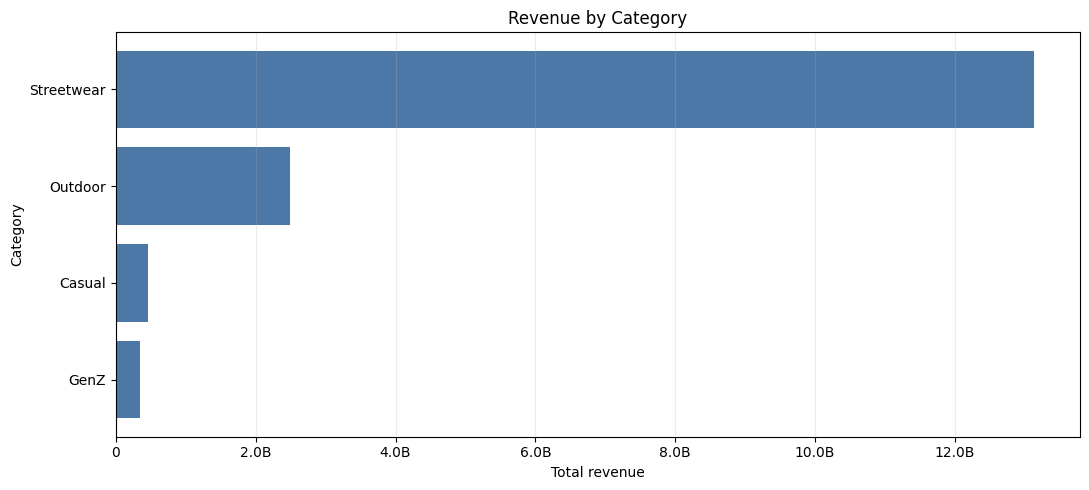

In [6]:
if not analysis_ready:
    print("WARNING: Skipping revenue by category because the joined dataset is not available.")
else:
    total_revenue = category_items["revenue"].sum()
    category_revenue = (
        category_items.groupby("category", dropna=False)
        .agg(
            total_revenue=("revenue", "sum"),
            number_of_orders=("order_id", "nunique"),
            number_of_order_items=("revenue", "size"),
            number_of_unique_products=("product_id", "nunique"),
            average_revenue_per_order_item=("revenue", "mean"),
        )
        .sort_values("total_revenue", ascending=False)
        .reset_index()
    )
    category_revenue["revenue_share"] = category_revenue["total_revenue"] / total_revenue if total_revenue else np.nan
    category_revenue["rank_by_total_revenue"] = np.arange(1, len(category_revenue) + 1)

    top_category_names = category_revenue.head(5)["category"].astype(str).tolist()
    bottom_category_names = category_revenue.tail(5)["category"].astype(str).tolist()

    display(category_revenue)
    print("Top revenue categories:", ", ".join(top_category_names))
    print("Bottom revenue categories:", ", ".join(bottom_category_names))

    plot_df = category_revenue.head(20).sort_values("total_revenue", ascending=True)
    fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(plot_df))))
    ax.barh(plot_df["category"].astype(str), plot_df["total_revenue"], color="#4C78A8")
    ax.set_title("Revenue by Category")
    ax.set_xlabel("Total revenue")
    ax.set_ylabel("Category")
    ax.xaxis.set_major_formatter(currency_axis)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 7. Revenue concentration analysis

Calculate cumulative revenue share by category and identify how many categories explain 50%, 80%, and 90% of total revenue.

,category_count,top_1_revenue_share,top_3_revenue_share,categories_for_50pct_revenue,categories_for_80pct_revenue,categories_for_90pct_revenue,concentration_statement
0,4,0.799207,0.979088,1,2,2,Revenue appears concentrated: 2 categories explain 80% of total revenue.


,category,total_revenue,number_of_orders,number_of_order_items,number_of_unique_products,average_revenue_per_order_item,revenue_share,rank_by_total_revenue,cumulative_revenue,cumulative_revenue_share
0,Streetwear,1.313135e+10,389543,393533,877,33367.840442,0.799207,1,1.313135e+10,0.799207
1,Outdoor,2.494883e+09,200454,259986,496,9596.219620,0.151845,2,1.562623e+10,0.951051
2,Casual,4.606484e+08,23600,23991,114,19200.882971,0.028036,3,1.608688e+10,0.979088
3,GenZ,3.435991e+08,37054,37159,111,9246.726106,0.020912,4,1.643048e+10,1.000000


Revenue appears concentrated: 2 categories explain 80% of total revenue.


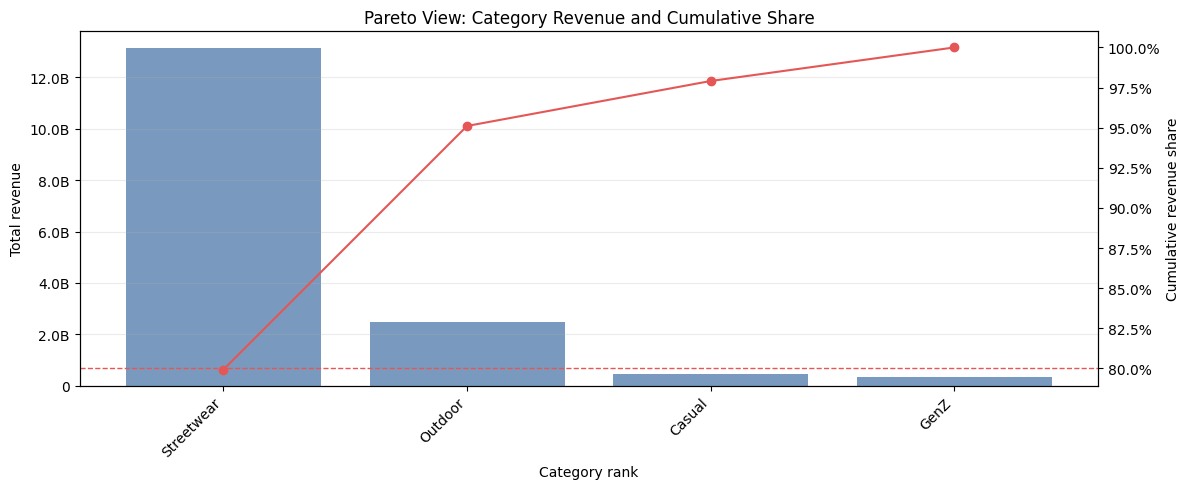

In [7]:
def categories_needed_for_share(df, threshold):
    eligible = df.loc[df["cumulative_revenue_share"] >= threshold]
    return int(eligible.iloc[0]["rank_by_total_revenue"]) if not eligible.empty else np.nan


if not analysis_ready or category_revenue.empty:
    print("WARNING: Skipping concentration analysis because category revenue is not available.")
else:
    concentration_df = category_revenue.copy()
    concentration_df["cumulative_revenue"] = concentration_df["total_revenue"].cumsum()
    concentration_df["cumulative_revenue_share"] = concentration_df["revenue_share"].cumsum()
    categories_for_50 = categories_needed_for_share(concentration_df, 0.50)
    categories_for_80 = categories_needed_for_share(concentration_df, 0.80)
    categories_for_90 = categories_needed_for_share(concentration_df, 0.90)
    top1_share = concentration_df.iloc[0]["revenue_share"] if len(concentration_df) else np.nan
    top3_share = concentration_df.head(3)["revenue_share"].sum()

    if pd.notna(categories_for_80) and categories_for_80 <= max(2, len(concentration_df) * 0.25):
        concentration_statement = f"Revenue appears concentrated: {categories_for_80} categories explain 80% of total revenue."
    else:
        concentration_statement = f"Revenue appears less concentrated: {categories_for_80} categories are needed to explain 80% of total revenue."

    summary_df = pd.DataFrame([{
        "category_count": len(concentration_df),
        "top_1_revenue_share": top1_share,
        "top_3_revenue_share": top3_share,
        "categories_for_50pct_revenue": categories_for_50,
        "categories_for_80pct_revenue": categories_for_80,
        "categories_for_90pct_revenue": categories_for_90,
        "concentration_statement": concentration_statement,
    }])
    display(summary_df)
    display(concentration_df)
    print(concentration_statement)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    x = np.arange(len(concentration_df))
    ax1.bar(x, concentration_df["total_revenue"], color="#4C78A8", alpha=0.75)
    ax1.set_xlabel("Category rank")
    ax1.set_ylabel("Total revenue")
    ax1.yaxis.set_major_formatter(currency_axis)
    ax2 = ax1.twinx()
    ax2.plot(x, concentration_df["cumulative_revenue_share"], color="#E45756", marker="o", linewidth=1.5)
    ax2.axhline(0.80, color="#E45756", linestyle="--", linewidth=1)
    ax2.set_ylabel("Cumulative revenue share")
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax1.set_title("Pareto View: Category Revenue and Cumulative Share")
    ax1.set_xticks(x)
    ax1.set_xticklabels(concentration_df["category"].astype(str), rotation=45, ha="right")
    ax1.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. Category monthly revenue trends

Aggregate category revenue by month and plot the top categories by total revenue. Crowded charts are limited to the top categories for readability.

Monthly category revenue table


,month,category,monthly_revenue,monthly_orders,monthly_items
0,2012-07-01,Casual,2.383589e+06,135,136
1,2012-07-01,GenZ,2.251165e+06,314,315
2,2012-07-01,Outdoor,1.772369e+07,1584,2117
3,2012-07-01,Streetwear,1.080483e+08,3283,3319
4,2012-08-01,Casual,2.606050e+06,129,129
5,2012-08-01,GenZ,2.529212e+06,342,343
6,2012-08-01,Outdoor,2.619934e+07,2223,2868
7,2012-08-01,Streetwear,1.277546e+08,3784,3826
8,2012-09-01,Casual,1.833064e+06,106,106
9,2012-09-01,GenZ,1.671792e+06,235,235


Monthly category revenue pivot preview


category,Streetwear,Outdoor,Casual,GenZ
month,,,,
2012-07-01,1.080483e+08,17723691.11,2383588.69,2251165.29
2012-08-01,1.277546e+08,26199339.48,2606049.57,2529211.73
2012-09-01,9.964239e+07,26159883.72,1833063.92,1671792.07
2012-10-01,8.495371e+07,22213347.80,1813957.84,1204681.44
2012-11-01,7.067177e+07,25309306.02,1497087.90,708131.37
2012-12-01,6.701571e+07,44566551.65,1594790.42,1145561.38
2013-01-01,6.600306e+07,22858162.81,1754302.63,693151.02
2013-02-01,8.328914e+07,23411468.63,2350419.14,732111.16
2013-03-01,1.188466e+08,28556516.26,2789209.83,1642340.47


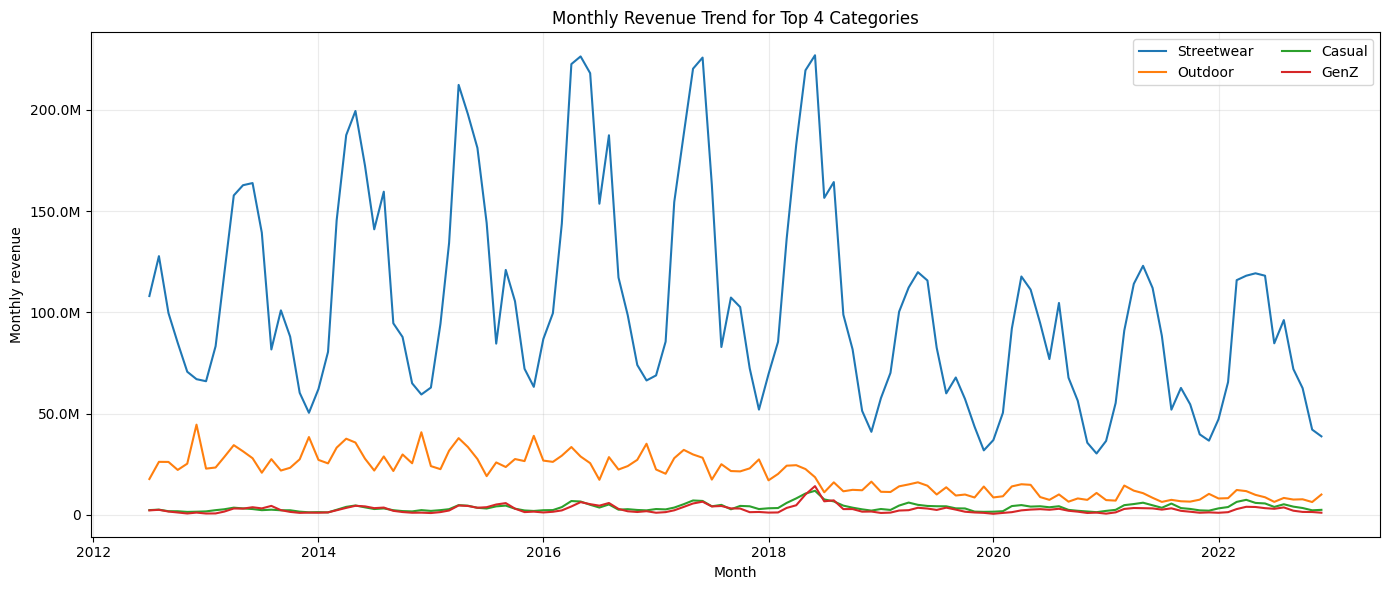

In [8]:
if not analysis_ready:
    print("WARNING: Skipping monthly category trends because the joined dataset is not available.")
else:
    monthly_category = (
        category_items.groupby(["month", "category"], as_index=False)
        .agg(monthly_revenue=("revenue", "sum"), monthly_orders=("order_id", "nunique"), monthly_items=("revenue", "size"))
        .sort_values(["month", "category"])
    )
    full_months = pd.date_range(category_items["month"].min(), category_items["month"].max(), freq="MS")
    monthly_pivot = (
        monthly_category.pivot(index="month", columns="category", values="monthly_revenue")
        .reindex(full_months)
        .fillna(0)
    )
    monthly_pivot.index.name = "month"
    top_categories = category_revenue.head(TOP_N_CATEGORIES)["category"].tolist()

    print("Monthly category revenue table")
    display(monthly_category.head(30))
    print("Monthly category revenue pivot preview")
    display(monthly_pivot[top_categories].head(12))

    fig, ax = plt.subplots(figsize=(14, 6))
    for category in top_categories:
        ax.plot(monthly_pivot.index, monthly_pivot[category], label=str(category), linewidth=1.5)
    ax.set_title(f"Monthly Revenue Trend for Top {len(top_categories)} Categories")
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## 9. Category growth and decline analysis

Calculate growth indicators by category while applying minimum revenue and observation thresholds before labeling meaningful growth or decline.

Category growth indicators


,category,total_revenue,observed_months,first_available_month,first_available_month_revenue,last_timeline_month,last_timeline_month_revenue,absolute_change_first_to_last,percentage_change_first_to_last,recent_6_month_avg,earlier_avg_before_recent_6,recent_6_vs_earlier_abs,recent_6_vs_earlier_pct,compound_monthly_growth_rate,monthly_revenue_volatility,monthly_coefficient_of_variation,meets_meaningful_threshold
0,Casual,4.606484e+08,126,2012-07-01,2.383589e+06,2022-12-01,2503179.08,119590.39,5.017241,3.583320e+06,3.659571e+06,-7.625098e+04,-2.083605,0.000392,1.832685e+06,0.501290,True
1,GenZ,3.435991e+08,126,2012-07-01,2.251165e+06,2022-12-01,1094830.37,-1156334.92,-51.366060,2.137786e+06,2.756436e+06,-6.186501e+05,-22.443836,-0.005750,1.917993e+06,0.703340,True
2,Outdoor,2.494883e+09,126,2012-07-01,1.772369e+07,2022-12-01,10068567.98,-7655123.13,-43.191472,7.761775e+06,2.040260e+07,-1.264083e+07,-61.956935,-0.004514,9.500237e+06,0.479794,True
3,Streetwear,1.313135e+10,126,2012-07-01,1.080483e+08,2022-12-01,38788358.77,-69259969.65,-64.100917,6.606687e+07,1.061245e+08,-4.005768e+07,-37.745913,-0.008162,5.093551e+07,0.488745,True


Fastest-growing categories by recent 6-month average vs earlier average


,category,total_revenue,observed_months,first_available_month,first_available_month_revenue,last_timeline_month,last_timeline_month_revenue,absolute_change_first_to_last,percentage_change_first_to_last,recent_6_month_avg,earlier_avg_before_recent_6,recent_6_vs_earlier_abs,recent_6_vs_earlier_pct,compound_monthly_growth_rate,monthly_revenue_volatility,monthly_coefficient_of_variation,meets_meaningful_threshold


Fastest-declining categories by recent 6-month average vs earlier average


,category,total_revenue,observed_months,first_available_month,first_available_month_revenue,last_timeline_month,last_timeline_month_revenue,absolute_change_first_to_last,percentage_change_first_to_last,recent_6_month_avg,earlier_avg_before_recent_6,recent_6_vs_earlier_abs,recent_6_vs_earlier_pct,compound_monthly_growth_rate,monthly_revenue_volatility,monthly_coefficient_of_variation,meets_meaningful_threshold
3,Streetwear,1.313135e+10,126,2012-07-01,1.080483e+08,2022-12-01,38788358.77,-69259969.65,-64.100917,6.606687e+07,1.061245e+08,-4.005768e+07,-37.745913,-0.008162,5.093551e+07,0.488745,True
2,Outdoor,2.494883e+09,126,2012-07-01,1.772369e+07,2022-12-01,10068567.98,-7655123.13,-43.191472,7.761775e+06,2.040260e+07,-1.264083e+07,-61.956935,-0.004514,9.500237e+06,0.479794,True
1,GenZ,3.435991e+08,126,2012-07-01,2.251165e+06,2022-12-01,1094830.37,-1156334.92,-51.366060,2.137786e+06,2.756436e+06,-6.186501e+05,-22.443836,-0.005750,1.917993e+06,0.703340,True
0,Casual,4.606484e+08,126,2012-07-01,2.383589e+06,2022-12-01,2503179.08,119590.39,5.017241,3.583320e+06,3.659571e+06,-7.625098e+04,-2.083605,0.000392,1.832685e+06,0.501290,True


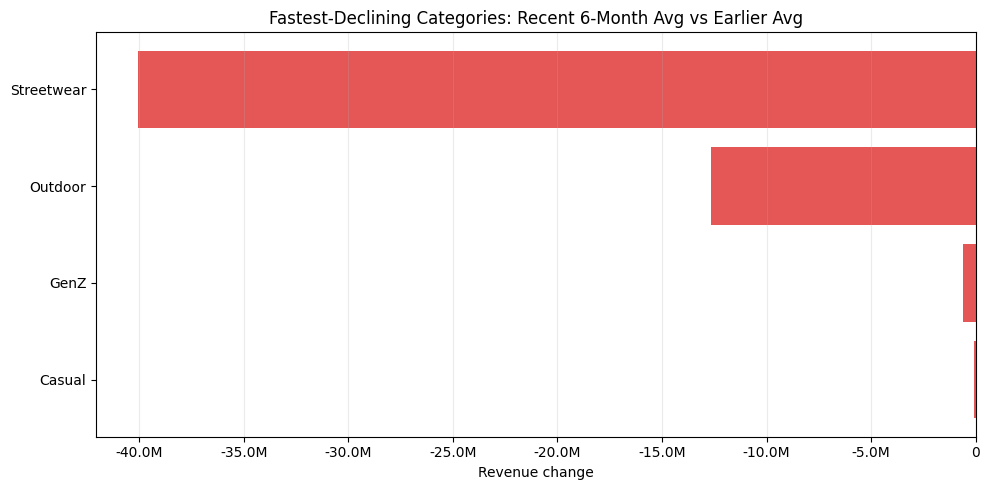

In [9]:
if not analysis_ready or monthly_pivot.empty:
    print("WARNING: Skipping category growth analysis because monthly category revenue is not available.")
else:
    total_revenue_all = category_items["revenue"].sum()
    min_total_revenue = max(total_revenue_all * 0.005, 1)
    rows = []
    for category in monthly_pivot.columns:
        series = monthly_pivot[category].astype(float)
        positive = series[series > 0]
        total_cat_revenue = series.sum()
        observed_months = int((series > 0).sum())
        if positive.empty:
            continue
        first_month = positive.index[0]
        last_month = series.index[-1]
        first_revenue = float(series.loc[first_month])
        last_revenue = float(series.loc[last_month])
        absolute_change = last_revenue - first_revenue
        safe_start = first_revenue >= max(series[series > 0].median() * 0.10, 1)
        percentage_change = absolute_change / first_revenue * 100 if safe_start and first_revenue != 0 else np.nan
        recent_6_avg = float(series.tail(6).mean()) if len(series) >= 1 else np.nan
        earlier_window = series.iloc[:-6] if len(series) > 6 else series.iloc[:0]
        earlier_avg = float(earlier_window.mean()) if len(earlier_window) else np.nan
        recent_vs_earlier_abs = recent_6_avg - earlier_avg if pd.notna(earlier_avg) else np.nan
        recent_vs_earlier_pct = recent_vs_earlier_abs / earlier_avg * 100 if pd.notna(earlier_avg) and abs(earlier_avg) > 1e-9 else np.nan
        months_between = max(1, (last_month.year - first_month.year) * 12 + (last_month.month - first_month.month))
        cmgr = (last_revenue / first_revenue) ** (1 / months_between) - 1 if first_revenue > 0 and last_revenue > 0 else np.nan
        volatility = float(series.std(ddof=1)) if len(series) > 1 else np.nan
        coefficient_of_variation = volatility / abs(series.mean()) if series.mean() != 0 else np.nan
        meaningful = bool(total_cat_revenue >= min_total_revenue and observed_months >= 6)
        rows.append({
            "category": category,
            "total_revenue": total_cat_revenue,
            "observed_months": observed_months,
            "first_available_month": first_month,
            "first_available_month_revenue": first_revenue,
            "last_timeline_month": last_month,
            "last_timeline_month_revenue": last_revenue,
            "absolute_change_first_to_last": absolute_change,
            "percentage_change_first_to_last": percentage_change,
            "recent_6_month_avg": recent_6_avg,
            "earlier_avg_before_recent_6": earlier_avg,
            "recent_6_vs_earlier_abs": recent_vs_earlier_abs,
            "recent_6_vs_earlier_pct": recent_vs_earlier_pct,
            "compound_monthly_growth_rate": cmgr,
            "monthly_revenue_volatility": volatility,
            "monthly_coefficient_of_variation": coefficient_of_variation,
            "meets_meaningful_threshold": meaningful,
        })
    growth_df = pd.DataFrame(rows).sort_values("recent_6_vs_earlier_abs", ascending=False)

    meaningful_growth = growth_df.loc[growth_df["meets_meaningful_threshold"]].copy()
    fastest_growing_df = meaningful_growth.loc[meaningful_growth["recent_6_vs_earlier_abs"] > 0].sort_values(["recent_6_vs_earlier_abs", "recent_6_vs_earlier_pct"], ascending=False).head(10)
    fastest_declining_df = meaningful_growth.loc[meaningful_growth["recent_6_vs_earlier_abs"] < 0].sort_values(["recent_6_vs_earlier_abs", "recent_6_vs_earlier_pct"], ascending=True).head(10)

    print("Category growth indicators")
    display(growth_df)
    print("Fastest-growing categories by recent 6-month average vs earlier average")
    display(fastest_growing_df)
    print("Fastest-declining categories by recent 6-month average vs earlier average")
    display(fastest_declining_df)

    if not fastest_growing_df.empty:
        plot_df = fastest_growing_df.sort_values("recent_6_vs_earlier_abs")
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(plot_df["category"].astype(str), plot_df["recent_6_vs_earlier_abs"], color="#54A24B")
        ax.set_title("Fastest-Growing Categories: Recent 6-Month Avg vs Earlier Avg")
        ax.set_xlabel("Revenue change")
        ax.xaxis.set_major_formatter(currency_axis)
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()

    if not fastest_declining_df.empty:
        plot_df = fastest_declining_df.sort_values("recent_6_vs_earlier_abs", ascending=False)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(plot_df["category"].astype(str), plot_df["recent_6_vs_earlier_abs"], color="#E45756")
        ax.set_title("Fastest-Declining Categories: Recent 6-Month Avg vs Earlier Avg")
        ax.set_xlabel("Revenue change")
        ax.xaxis.set_major_formatter(currency_axis)
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()

## 10. Category revenue share over time

Calculate category share of monthly revenue and show how category mix changes over time. For readability, top categories are shown individually and remaining categories are grouped as `Other`.

,average_top1_monthly_share,latest_top1_monthly_share,top1_share_change_first_to_last_month,average_monthly_category_hhi,latest_monthly_category_hhi,avg_abs_monthly_share_change_top_categories,mix_change_statement
0,0.787619,0.739461,-0.089088,0.658021,0.586359,0.023986,Category mix changes over time: average absolute monthly share movement among top categories is 2.40%.


Category mix changes over time: average absolute monthly share movement among top categories is 2.40%.


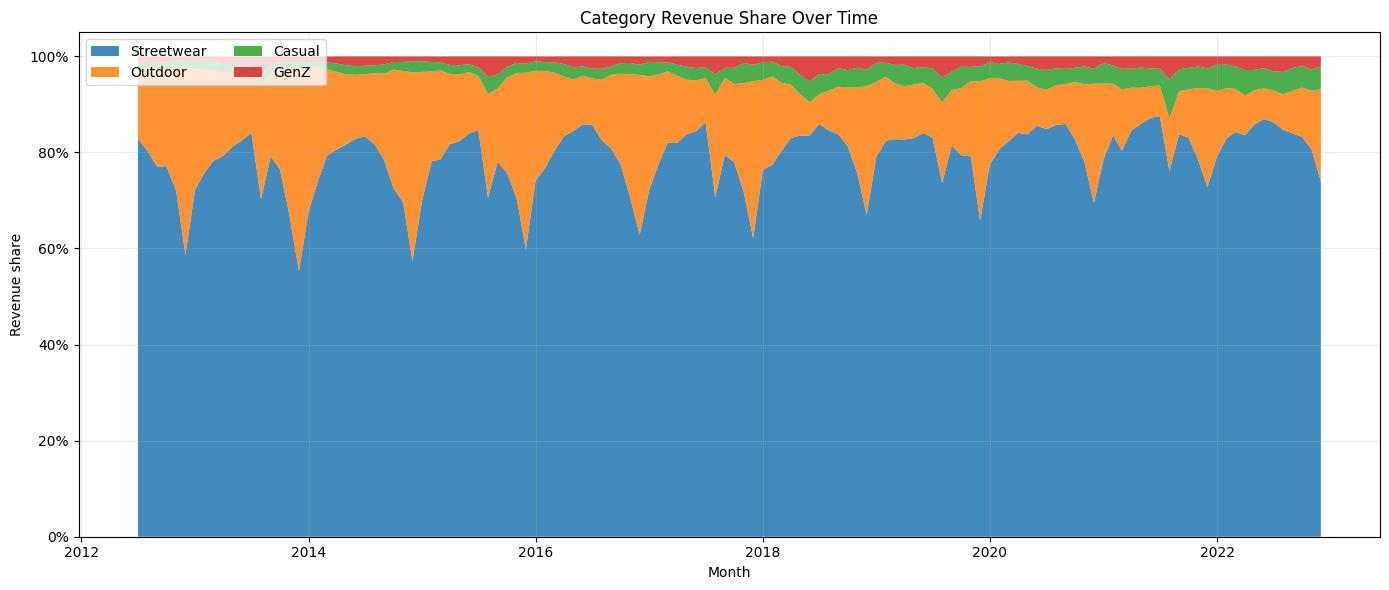

In [10]:
if not analysis_ready or monthly_pivot.empty:
    print("WARNING: Skipping category revenue share over time because monthly category revenue is not available.")
else:
    top_share_categories = category_revenue.head(min(TOP_N_CATEGORIES, len(category_revenue)))["category"].tolist()
    share_source = monthly_pivot.copy()
    total_monthly_revenue = share_source.sum(axis=1)
    monthly_share = share_source.div(total_monthly_revenue.replace(0, np.nan), axis=0).fillna(0)

    monthly_share_plot_df = monthly_share[top_share_categories].copy()
    other_categories = [col for col in monthly_share.columns if col not in top_share_categories]
    if other_categories:
        monthly_share_plot_df["Other"] = monthly_share[other_categories].sum(axis=1)

    top1_share_by_month = monthly_share.max(axis=1)
    hhi_by_month = (monthly_share ** 2).sum(axis=1)
    avg_abs_share_change = monthly_share[top_share_categories].diff().abs().mean().mean()
    top1_change = top1_share_by_month.iloc[-1] - top1_share_by_month.iloc[0] if len(top1_share_by_month) > 1 else np.nan
    if pd.notna(avg_abs_share_change) and avg_abs_share_change >= 0.015:
        mix_change_statement = f"Category mix changes over time: average absolute monthly share movement among top categories is {avg_abs_share_change:.2%}."
    else:
        mix_change_statement = f"Category mix appears relatively stable: average absolute monthly share movement among top categories is {avg_abs_share_change:.2%}."

    mix_summary_df = pd.DataFrame([{
        "average_top1_monthly_share": top1_share_by_month.mean(),
        "latest_top1_monthly_share": top1_share_by_month.iloc[-1],
        "top1_share_change_first_to_last_month": top1_change,
        "average_monthly_category_hhi": hhi_by_month.mean(),
        "latest_monthly_category_hhi": hhi_by_month.iloc[-1],
        "avg_abs_monthly_share_change_top_categories": avg_abs_share_change,
        "mix_change_statement": mix_change_statement,
    }])
    display(mix_summary_df)
    print(mix_change_statement)

    fig, ax = plt.subplots(figsize=(14, 6))
    labels = [str(col) for col in monthly_share_plot_df.columns]
    ax.stackplot(monthly_share_plot_df.index, [monthly_share_plot_df[col] for col in monthly_share_plot_df.columns], labels=labels, alpha=0.85)
    ax.set_title("Category Revenue Share Over Time")
    ax.set_xlabel("Month")
    ax.set_ylabel("Revenue share")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", ncol=2)
    plt.tight_layout()
    plt.show()

## 11. Leakage-safe category forecast feature preview

Create daily category-mix feature examples using only historical category information. Future category mix must not be used directly for forecasting unless category demand is separately forecasted.

In [11]:
if not analysis_ready:
    print("WARNING: Skipping forecast feature preview because the joined dataset is not available.")
else:
    daily_category = (
        category_items.groupby(["order_date", "category"], as_index=False)
        .agg(revenue=("revenue", "sum"))
    )
    daily_pivot = daily_category.pivot(index="order_date", columns="category", values="revenue").fillna(0)
    full_days = pd.date_range(daily_pivot.index.min(), daily_pivot.index.max(), freq="D")
    daily_pivot = daily_pivot.reindex(full_days).fillna(0)
    daily_pivot.index.name = "date"
    daily_total = daily_pivot.sum(axis=1)

    global_top_category = category_revenue.iloc[0]["category"] if not category_revenue.empty else daily_pivot.columns[0]
    shifted_category = daily_pivot.shift(1)
    shifted_total = daily_total.shift(1)
    rolling_category_30 = shifted_category.rolling(window=30, min_periods=7).sum()
    rolling_total_30 = rolling_category_30.sum(axis=1)
    rolling_shares_30 = rolling_category_30.div(rolling_total_30.replace(0, np.nan), axis=0)

    feature_df = pd.DataFrame({
        "date": daily_pivot.index,
        "total_revenue": daily_total.values,
        "top_category_revenue_lag": shifted_category[global_top_category].values if global_top_category in shifted_category.columns else np.nan,
        "category_revenue_share_lag_30": rolling_shares_30[global_top_category].values if global_top_category in rolling_shares_30.columns else np.nan,
        "category_mix_lag_30": rolling_shares_30.idxmax(axis=1).astype("string").values,
        "top_1_category_share_lag_30": rolling_shares_30.max(axis=1).values,
        "top_3_category_share_lag_30": rolling_shares_30.apply(lambda row: row.dropna().sort_values(ascending=False).head(3).sum(), axis=1).values,
        "category_concentration_lag_30": (rolling_shares_30.fillna(0) ** 2).sum(axis=1).values,
    })

    feature_preview = feature_df.dropna(subset=["category_revenue_share_lag_30"]).head(20)
    if feature_preview.empty:
        feature_preview = feature_df.head(20)
    display(feature_preview)
    print("Leakage-safe construction: category revenue is shifted by one day before 30-day rolling category shares and concentration are calculated.")
    print(forecast_feature_warning)
    print("Recommended category-level forecast features:", ", ".join(recommended_category_features))

,date,total_revenue,top_category_revenue_lag,category_revenue_share_lag_30,category_mix_lag_30,top_1_category_share_lag_30,top_3_category_share_lag_30,category_concentration_lag_30
7,2012-07-11,5582884.78,4622272.80,0.895793,Streetwear,0.895793,0.987723,0.808741
8,2012-07-12,5734632.02,4642755.59,0.883976,Streetwear,0.883976,0.987927,0.789619
9,2012-07-13,5309511.71,4763417.28,0.875494,Streetwear,0.875494,0.986728,0.776077
10,2012-07-14,3820831.41,4569734.72,0.873591,Streetwear,0.873591,0.986463,0.773255
11,2012-07-15,3948841.28,3190744.19,0.870336,Streetwear,0.870336,0.985855,0.768094
12,2012-07-16,3503801.49,3425816.32,0.870112,Streetwear,0.870112,0.985670,0.767724
13,2012-07-17,4476729.49,2829954.14,0.865957,Streetwear,0.865957,0.984332,0.760808
14,2012-07-18,5184141.46,3625745.87,0.861564,Streetwear,0.861564,0.983287,0.753752
15,2012-07-19,6421487.11,4394832.66,0.860414,Streetwear,0.860414,0.983632,0.752014
16,2012-07-20,5171470.46,5098415.20,0.854205,Streetwear,0.854205,0.983011,0.742247


Leakage-safe construction: category revenue is shifted by one day before 30-day rolling category shares and concentration are calculated.
Future category mix must not be used directly for forecasting unless it is separately forecasted.
Recommended category-level forecast features: top_category_revenue_lag, category_revenue_share_lag_30, category_mix_lag_30, top_1_category_share_lag_30, top_3_category_share_lag_30, category_concentration_lag_30


## 12. Key observations and warnings

Summarize top revenue categories, concentration, growth/decline, category-mix change, and leakage-safe forecast feature recommendations.

In [12]:
if analysis_ready and not category_revenue.empty:
    top_categories_text = ", ".join(
        f"{row.category} ({row.revenue_share:.1%})"
        for row in category_revenue.head(5).itertuples()
    )
    contribution_text = ", ".join(
        f"{row.category}: {row.total_revenue:,.0f}"
        for row in category_revenue.head(3).itertuples()
    )
    if not fastest_growing_df.empty:
        growing_text = ", ".join(
            f"{row.category} ({row.recent_6_vs_earlier_abs:+,.0f})"
            for row in fastest_growing_df.head(3).itertuples()
        )
    else:
        growing_text = "None identified with thresholds"
    if not fastest_declining_df.empty:
        declining_text = ", ".join(
            f"{row.category} ({row.recent_6_vs_earlier_abs:,.0f})"
            for row in fastest_declining_df.head(3).itertuples()
        )
    else:
        declining_text = "None identified with thresholds"

    core_categories = category_revenue.head(3)["category"].astype(str).tolist()
    high_vol_categories = (
        growth_df.loc[growth_df["meets_meaningful_threshold"]]
        .sort_values("monthly_coefficient_of_variation", ascending=False)
        .head(3)["category"]
        .astype(str)
        .tolist()
        if not growth_df.empty else []
    )
    attention_text = (
        "Core revenue/inventory attention: " + ", ".join(core_categories)
        + ("; volatility monitoring: " + ", ".join(high_vol_categories) if high_vol_categories else "")
    )

    print("Insight summary")
    print(f"- Top revenue categories: {top_categories_text}")
    print(f"- Categories contributing most revenue: {contribution_text}")
    print(f"- Revenue concentration: {concentration_statement}")
    print(f"- Fastest-growing categories: {growing_text}")
    print(f"- Fastest-declining categories: {declining_text}")
    print(f"- Category mix over time: {mix_change_statement}")
    print(f"- Category groups that may deserve inventory or marketing attention: {attention_text}")
    print(f"- Recommended leakage-safe category-level forecast features: {', '.join(recommended_category_features)}")
    print(f"- Forecasting warning: {forecast_feature_warning}")
else:
    print("Insight summary")
    print("- Category revenue analysis could not be completed because required joined data was not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Top revenue categories: Streetwear (79.9%), Outdoor (15.2%), Casual (2.8%), GenZ (2.1%)
- Categories contributing most revenue: Streetwear: 13,131,346,353, Outdoor: 2,494,882,754, Casual: 460,648,383
- Revenue concentration: Revenue appears concentrated: 2 categories explain 80% of total revenue.
- Fastest-growing categories: None identified with thresholds
- Fastest-declining categories: Streetwear (-40,057,677), Outdoor (-12,640,826), GenZ (-618,650)
- Category mix over time: Category mix changes over time: average absolute monthly share movement among top categories is 2.40%.
- Category groups that may deserve inventory or marketing attention: Core revenue/inventory attention: Streetwear, Outdoor, Casual; volatility monitoring: GenZ, Casual, Streetwear
- Recommended leakage-safe category-level forecast features: top_category_revenue_lag, category_revenue_share_lag_30, category_mix_lag_30, top_1_category_share_lag_30, top_3_category_share_lag_30, category_concentrat